In [1]:
import pandas as pd 
import numpy as np

In [2]:
df=pd.read_csv("placement.csv")
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.2 KB


In [4]:
df=df.iloc[:,1:]

In [5]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [6]:
import matplotlib.pyplot as plt

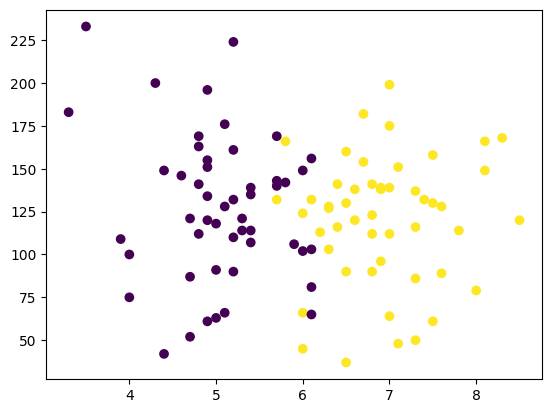

In [7]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [8]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [9]:
x.shape

(100, 2)

In [10]:
y.shape

(100,)

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test=train_test_split(x,y,test_size=0.1)

In [12]:
x_train

,cgpa,iq
69,8.5,120.0
83,7.5,130.0
46,5.3,114.0
25,5.0,91.0
10,6.0,45.0
...,...,...
31,3.9,109.0
56,6.1,65.0
1,5.9,106.0
62,6.0,102.0


In [13]:
y_train

69    1
83    1
46    0
25    0
10    1
     ..
31    0
56    0
1     0
62    0
9     0
Name: placement, Length: 90, dtype: int64

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)

In [16]:
x_train

array([[ 2.20121552, -0.11207736],
       [ 1.32268161,  0.13759993],
       [-0.61009299, -0.26188373],
       [-0.87365317, -0.83614149],
       [ 0.00488074, -1.984657  ],
       [-1.13721334, -1.8098829 ],
       [ 0.00488074, -0.01220645],
       [-1.13721334, -0.9360124 ],
       [-0.69794638,  2.4845664 ],
       [ 2.02550874,  1.08637361],
       [-0.96150656, -0.11207736],
       [-1.04935995,  1.11134134],
       [-0.78579978,  1.28611544],
       [ 0.88341466,  1.86037319],
       [ 0.88341466,  1.26114771],
       [ 1.84980196,  0.61198677],
       [-0.69794638,  0.18753538],
       [ 0.97126805, -1.90975381],
       [-0.25867943,  1.11134134],
       [-1.04935995,  0.96153497],
       [ 1.14697483, -0.96098013],
       [ 0.53200109, -0.11207736],
       [ 0.70770787,  0.41224494],
       [ 0.79556126,  0.36230948],
       [ 0.88341466,  0.36230948],
       [-0.96150656,  1.78547001],
       [ 0.18058753, -0.28685146],
       [-1.75218708, -1.23562514],
       [-1.40077351,

In [17]:
x_test=scaler.transform(x_test)
x_test

array([[ 1.23482822,  0.18753538],
       [-0.96150656, -1.58517334],
       [-1.22506673,  0.53708358],
       [-0.5222396 , -0.26188373],
       [-0.69794638, -0.36175464],
       [ 1.32268161,  0.83669632],
       [ 0.26844092,  0.08766447],
       [ 0.97126805,  0.66192222],
       [ 0.70770787, -0.31181919],
       [-1.40077351, -2.05956018]])

In [18]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()

In [19]:
clf.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
y_pred=clf.predict(x_test)

In [21]:
y_test

3     1
73    0
39    0
41    0
92    0
91    1
63    1
21    1
93    1
96    0
Name: placement, dtype: int64

In [22]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

1.0

In [24]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

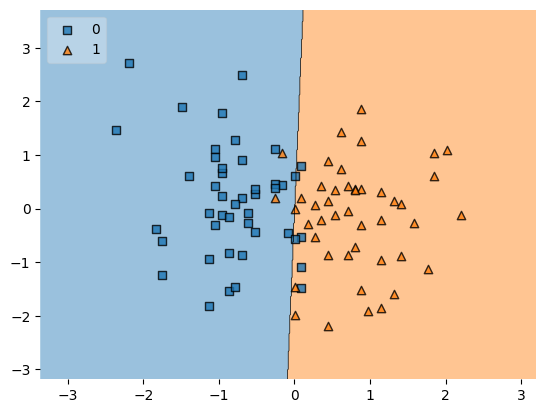

In [25]:
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [26]:
import pickle

In [27]:
pickle.dump(clf,open('model.pkl','wb'))